✅ Başarılı! 44376 satır eşleşti.


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


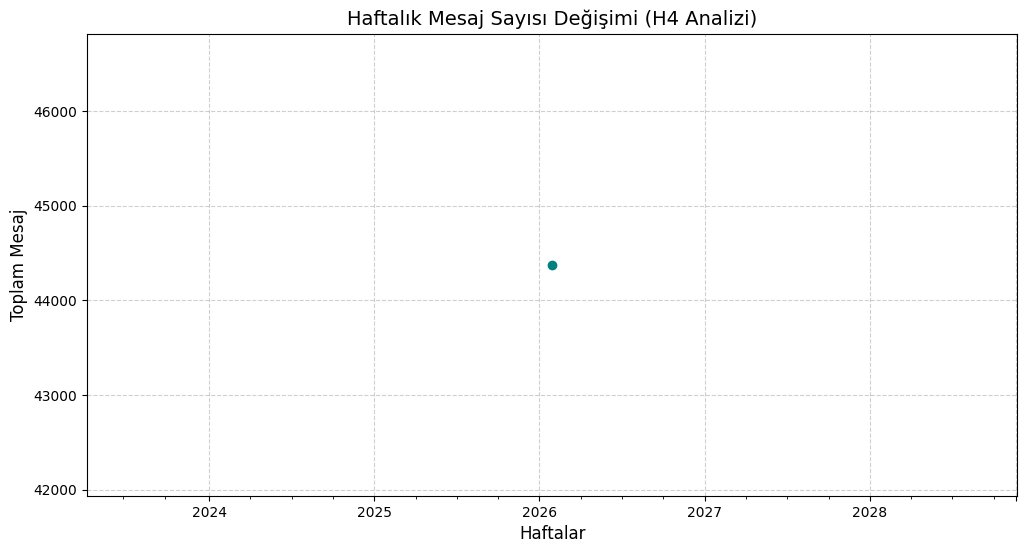

In [13]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dosyaları yükle
df_temiz = pd.read_csv('/content/moltbook_final_v4.csv')
df_ham = pd.read_csv('/content/moltbook_ham.csv')

# 2. ID Eşleşmesini garantiye al
df_temiz['id'] = df_temiz['id'].astype(str).str.lower().str.strip()
df_ham['id'] = df_ham['id'].astype(str).str.lower().str.strip()

# 3. Post içinden 'created_at' bilgisini çek
def get_time(post_str):
    try:
        # Metni sözlüğe çevir
        data = ast.literal_eval(post_str)
        # Anahtarımız 'created_at'
        return data.get('created_at')
    except:
        return None

df_ham['extracted_time'] = df_ham['post'].apply(get_time)

# 4. Birleştir (Sadece tarihleri temiz tabloya ekliyoruz)
df_final = pd.merge(df_temiz, df_ham[['id', 'extracted_time']], on='id', how='inner')

# 5. Tarih formatına çevir ve boşları at
df_final['extracted_time'] = pd.to_datetime(df_final['extracted_time'], errors='coerce')
df_final = df_final.dropna(subset=['extracted_time'])

# 6. Analiz ve Grafik
if df_final.empty:
    print("❌ Birleştirme başarısız oldu. ID'ler uyuşmuyor olabilir.")
else:
    # Tarihi indekse alıp haftalık gruplayalım
    df_final = df_final.set_index('extracted_time')
    haftalik = df_final.resample('W').size()

    print(f"✅ Başarılı! {len(df_final)} satır eşleşti.")

    plt.figure(figsize=(12, 6))
    haftalik.plot(kind='line', marker='o', color='teal', linewidth=2)
    plt.title('Haftalık Mesaj Sayısı Değişimi (H4 Analizi)', fontsize=14)
    plt.xlabel('Haftalar', fontsize=12)
    plt.ylabel('Toplam Mesaj', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()